In [14]:
# Import Basic Packgaes 
import numpy as np
import pandas as pd
import itertools
import glob
import os
from sklearn.preprocessing import MinMaxScaler

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.signal import argrelextrema

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
from scipy.interpolate import interp1d

# Set Color Palettes
palette1 = itertools.cycle(sns.color_palette(palette='Set1'))
palette2 = itertools.cycle(sns.color_palette(palette='Set2'))

In [15]:
directory_name = "D:\\1.5inch Pump Data\\P1_ASP-100,WDP-80\\P1_CSV_Files\\P1_15_All_freq_Plot\\New folder"

In [16]:
os.chdir(directory_name)

In [17]:
os.getcwd()

'D:\\1.5inch Pump Data\\P1_ASP-100,WDP-80\\P1_CSV_Files\\P1_15_All_freq_Plot\\New folder'

In [18]:
# current directory csv files
csvs = [x for x in os.listdir(directory_name) if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [19]:
dic_csv.keys()

dict_keys(['06.P1_15_100-80_1650Hrs_Sf3'])

# Cumulative freq Plot

In [ ]:
# Specify the column you want to extract
column_name = 'Cumulative_Amp'

# Create a new DataFrame to store the specified column from each DataFrame
result_df = pd.DataFrame()

# Loop through each key and DataFrame in dic_csv
for key, df in dic_csv.items():
    # Extract the specified column and add it to the result DataFrame
    result_df[key] = df[column_name]


In [ ]:
result_df

In [ ]:
len(result_df)

In [ ]:
diaphragm_hr = [n for n in np.arange(0,2050,(2050/len(result_df)))]

In [ ]:
len(diaphragm_hr)

In [ ]:
result_df['Diaphragm_life'] = diaphragm_hr

In [ ]:
result_df.set_index(['Diaphragm_life'], inplace=True)

In [ ]:
result_df.rename({'1.P1_2050Hrs_MultipleCracks_6.5to7.8MaxPoit&Cumsum':'T01_20_2050Hrs_10C',
                  '2.P2_78Hrs_Shaft Failed_6.5to7.8MaxPoit&Cumsum':'T02_20_78Hrs_2C',
                  '3.P3_ADS_failed_6.5to7.8Max Points & Cumsum':'T03_20_370Hrs_0C',
                  '4.P1_300Hrs(1500hrs Aged Diaphragm)_TwoCrack_6.5to7.8Max Points & Cumsum':'T04_20_300Hrs_2C',
                  '5.P1_91Hrs_TwoCrack_6.5to7.8MaxPoit&Cumsum':'T05_20_91Hrs_2C',
                  '6.P3_370Hrs_OneCrack_6.5to7.8MaxPoit&Cumsum':'T06_20_370Hrs_1C',
                  '7.P1_47Hrs_FourCrack_6.5to7.8MaxPoit&Cumsum':'T07_20_47Hrs_4C'},axis=1,inplace=True)


In [ ]:
marker_list = ['','','','','','','']

In [ ]:
plt.figure(figsize=(20,10))
for k, i in enumerate(result_df.columns):
    plt.plot(result_df[i], marker=marker_list[k], label = k)

plt.xlim(0,400)
plt.ylim(0,8000000)
plt.xlabel('Hrs')
plt.ylabel('Sf2_Cumsum_Amp')
plt.title('Diaphragm lifetime vs Amplitude')
plt.legend(result_df, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=10)

In [ ]:
result_df.to_csv(r"D:\\2Inch_Short test Cases_Cumsum_amp.csv")

In [ ]:
Norm_Sf2_df = pd.DataFrame()

In [ ]:

# perform a robust scaler transform of the dataset
Scaler = MinMaxScaler()
NormSf2_df = Scaler.fit_transform(result_df)
Norm_Sf2_df = pd.DataFrame(NormSf2_df,columns=result_df.columns)
Norm_Sf2_df['Diaphragm_life'] = diaphragm_hr
Norm_Sf2_df.set_index(['Diaphragm_life'], inplace=True)
Norm_Sf2_df.head()

In [ ]:
plt.figure(figsize=(40,15))
plt.plot(Norm_Sf2_df,marker = '.')

plt.xlabel('Hrs')
plt.ylabel('Sf2_Cumsum_Amp')
plt.title('Diaphragm lifetime vs Amplitude')
plt.legend(Norm_Sf2_df, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=10)

In [ ]:
plt.figure(figsize=(20,10))
for k, i in enumerate(Norm_Sf2_df.columns):
    plt.plot(Norm_Sf2_df[i], marker=marker_list[k], label = k)

plt.xlabel('Hrs')
plt.ylabel('Sf2_Cumsum_Amp')
plt.title('Diaphragm lifetime vs Amplitude')
plt.legend(Norm_Sf2_df, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=10)

In [ ]:
Cumusum_amp_slop = pd.DataFrame()

In [ ]:
for i in result_df.columns:
    Cumusum_amp_slop[i] = pd.DataFrame(np.gradient(result_df[i], edge_order=1))

In [ ]:
Cumusum_amp_slop['Diaphragm_life'] = diaphragm_hr

In [ ]:
Cumusum_amp_slop.set_index(['Diaphragm_life'], inplace=True)

In [ ]:
Cumusum_amp_slop

In [ ]:

fig, axes = plt.subplots(nrows=len(Cumusum_amp_slop.columns), ncols=1,figsize=(45,40))

for i, column in enumerate(Cumusum_amp_slop.columns):
    axes[i].plot(Cumusum_amp_slop[column],marker = '.')
    axes[i].set_title(column)

plt.show()


In [ ]:
plt.figure(figsize=(30,10))
for k, i in enumerate(Cumusum_amp_slop.columns):
    plt.plot(Cumusum_amp_slop[i], marker=marker_list[k], label = k)

plt.xlabel('Hrs')
plt.ylabel('Sf2_Cumsum_Amp')
plt.title('Diaphragm lifetime vs Amplitude')
plt.legend(Cumusum_amp_slop, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=10)

In [ ]:
Norm_Cumusum_amp_slop = pd.DataFrame()

In [ ]:
for i in Norm_Sf2_df.columns:
    Norm_Cumusum_amp_slop[i] = pd.DataFrame(np.gradient(Norm_Sf2_df[i]))

In [ ]:
Norm_Cumusum_amp_slop['Diaphragm_life'] = diaphragm_hr

In [ ]:
Norm_Cumusum_amp_slop.set_index(['Diaphragm_life'], inplace=True)

In [ ]:
plt.figure(figsize=(30,10))
for k, i in enumerate(Norm_Cumusum_amp_slop.columns):
    plt.plot(Norm_Cumusum_amp_slop[i], marker=marker_list[k], label = k)

plt.xlabel('Hrs')
plt.ylabel('Sf2_Cumsum_Amp')
plt.title('Diaphragm lifetime vs Amplitude')
plt.legend(Norm_Cumusum_amp_slop, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=10)

In [ ]:

fig, axes = plt.subplots(nrows=len(Norm_Cumusum_amp_slop.columns), ncols=1,figsize=(45,40))
for i, column in enumerate(Norm_Cumusum_amp_slop.columns):
    axes[i].plot(Norm_Cumusum_amp_slop[column])
    axes[i].set_title(column)
plt.show()

# Frequency Plot

In [20]:
P2_Merg_df = pd.concat(dic_csv.values(), ignore_index=True)

In [21]:
P2_Merg_df.reset_index(inplace=True, drop=True)

In [22]:
P2_Merg_df.head()

,Diaphragm_life,Frequency,Amplitude
0,0.000000,10.278194,301.142977
1,0.032336,10.311511,383.699873
2,0.064672,10.261536,393.107389
3,0.097007,10.194903,313.923549
4,0.129343,10.161586,347.249710


In [23]:
np.max(P2_Merg_df['Amplitude'])

1499.9486565772158

In [24]:
len(P2_Merg_df)

51027

In [29]:
Max_Eff = argrelextrema(P2_Merg_df['Amplitude'].values, np.greater_equal,order=100)[0]

In [30]:
P2_Merg_df['max_point'] = np.nan
P2_Merg_df.loc[Max_Eff, 'max_point'] = P2_Merg_df.loc[P2_Merg_df.index[Max_Eff], 'Amplitude']

In [ ]:
#P2_Merg_df.set_index(['Diaphragm_life'], inplace=True)

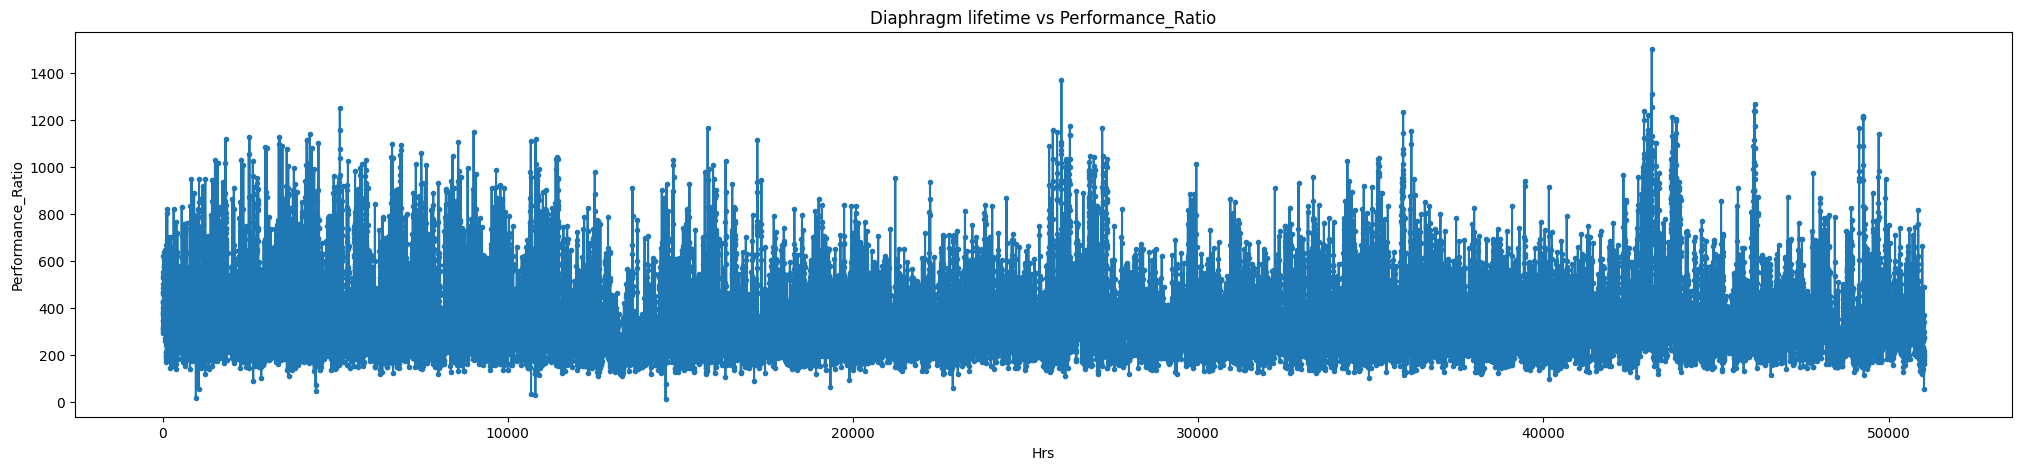

In [27]:
plt.figure(figsize=(25,5))
#plt.xticks(np.arange(np.min(Perf_df.index),np.max((Perf_df.index)),15))
plt.plot(P2_Merg_df.index,P2_Merg_df['Amplitude'],marker = '.')
plt.xlabel('Hrs')
plt.ylabel('Performance_Ratio')
plt.title('Diaphragm lifetime vs Performance_Ratio')
plt.show()

In [39]:
Max_points_freq = pd.DataFrame(Max_Eff)

In [31]:
f = interp1d(x=P2_Merg_df['Diaphragm_life'],y=P2_Merg_df['max_point'],kind=1)
x2 = np.linspace(start=0,stop=1649,num=1000)
y2 = f(x2)

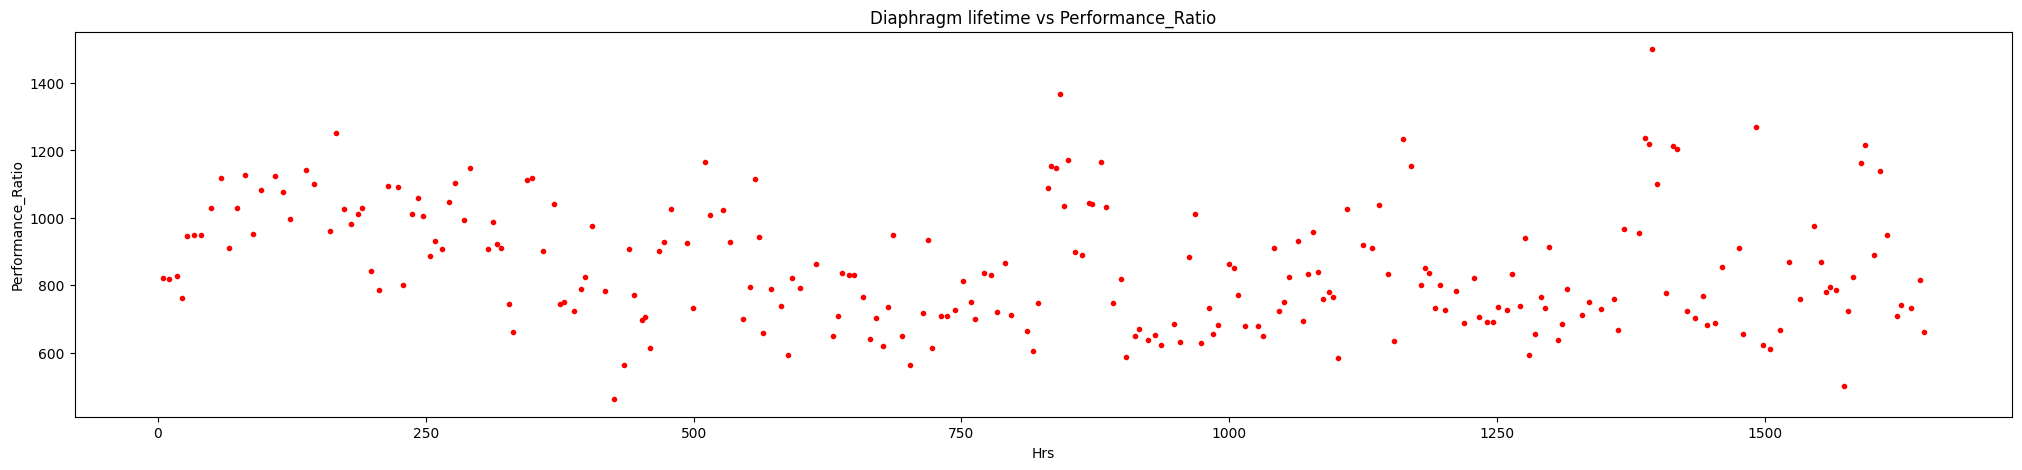

In [34]:
plt.figure(figsize=(25,5))
plt.plot(x2, y2, color='b')
plt.plot(P2_Merg_df['Diaphragm_life'], P2_Merg_df['max_point'], ls='', marker='.', color='r')
plt.xlabel('Hrs')
plt.ylabel('Performance_Ratio')
plt.title('Diaphragm lifetime vs Performance_Ratio')
plt.show()

Text(0, 0.5, 'Performance_Ratio')

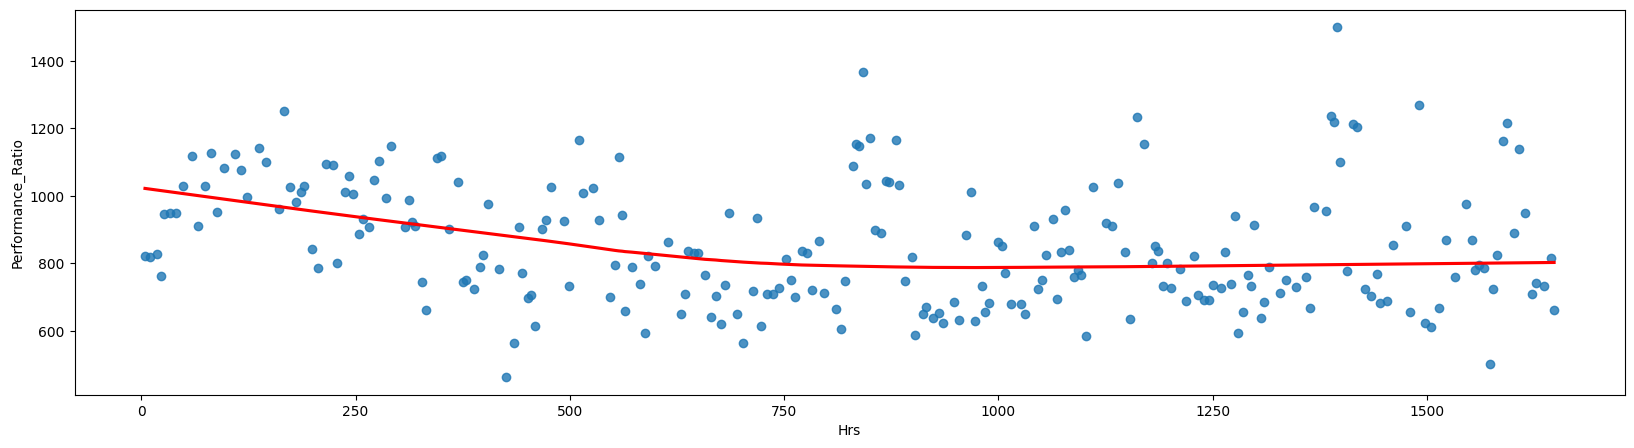

In [35]:
# set figure size 
plt.figure( figsize=(20,5)) 
#plt.xticks(np.arange(np.min(Perf_df.index),np.max((Perf_df.index)),15))
#plt.ylim(0.2,0.9)
sns.regplot(x=P2_Merg_df['Diaphragm_life'], y=P2_Merg_df['max_point'], lowess=True, line_kws={'color':'red'})
plt.xlabel('Hrs')
plt.ylabel('Performance_Ratio')

In [ ]:
P2_Merg_df.head()

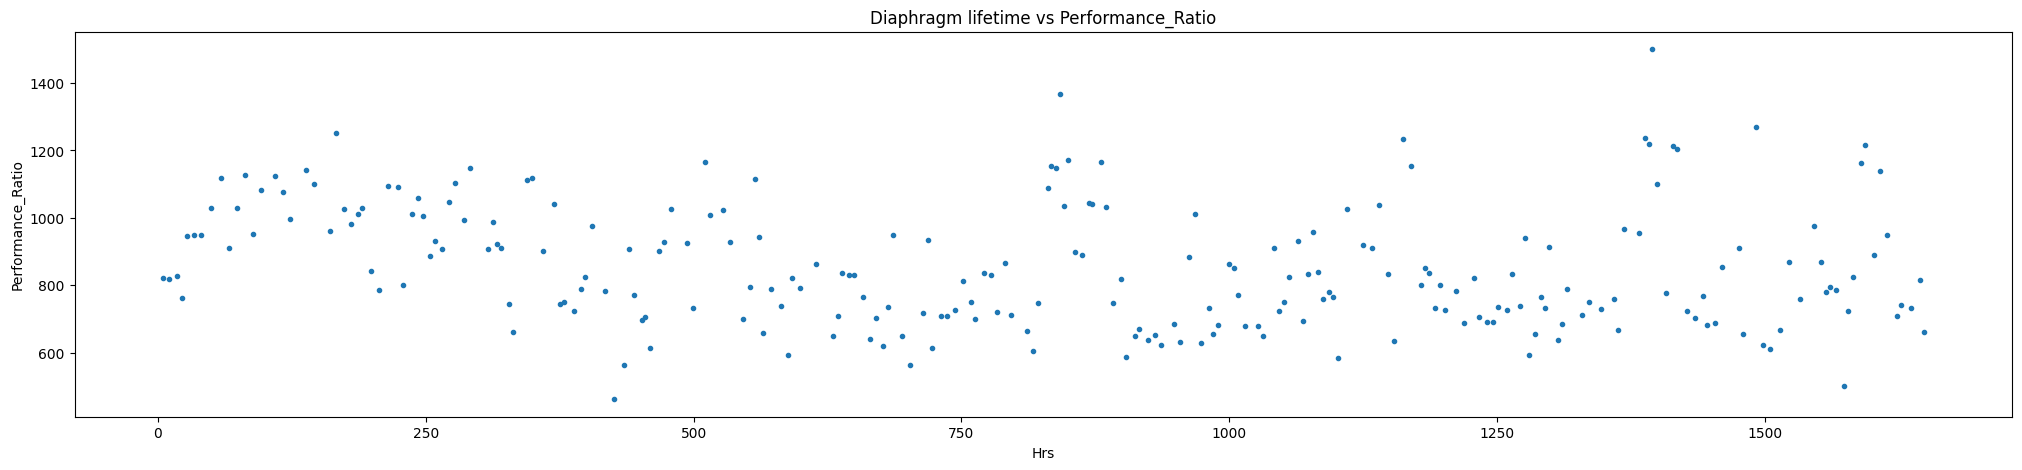

In [36]:
plt.figure(figsize=(25,5))
#plt.xticks(np.arange(np.min(Perf_df.index),np.max((Perf_df.index)),15))
plt.plot(P2_Merg_df['Diaphragm_life'],P2_Merg_df['max_point'],marker = '.')
plt.xlabel('Hrs')
plt.ylabel('Performance_Ratio')
plt.title('Diaphragm lifetime vs Performance_Ratio')
plt.show()

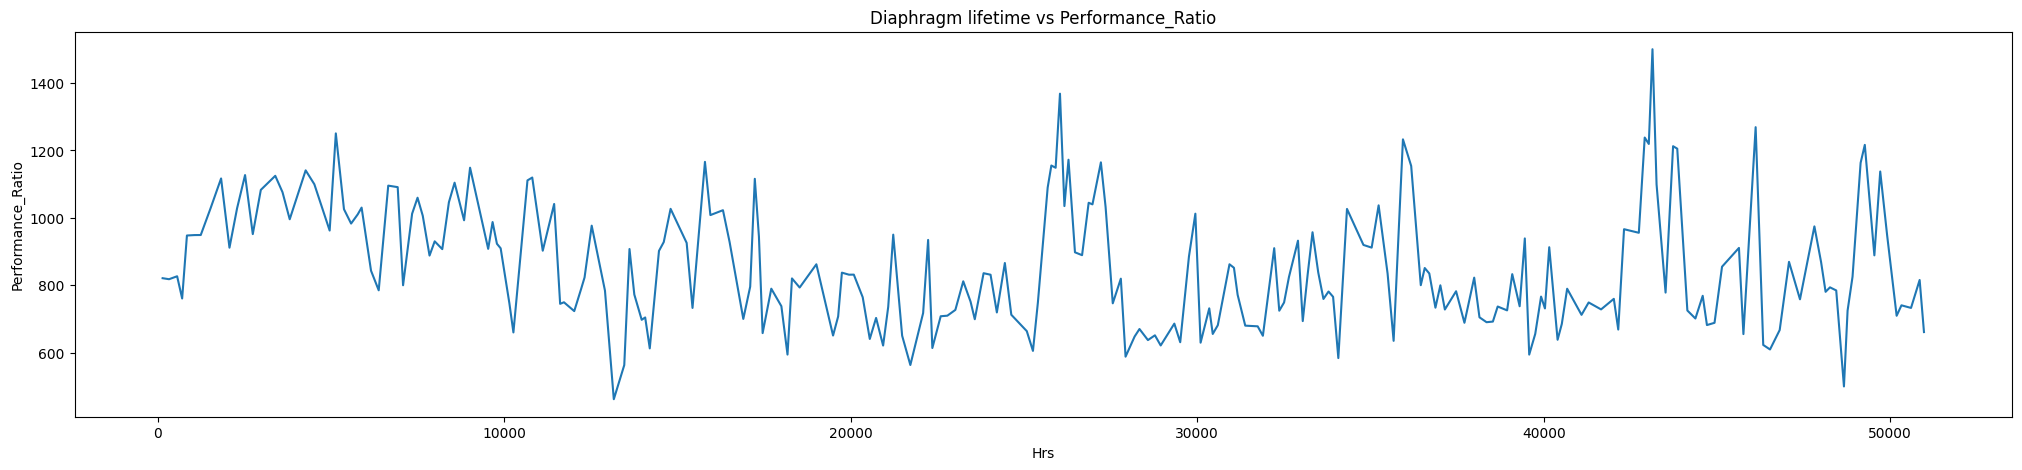

In [37]:
plt.figure(figsize=(25,5))
#plt.xticks(np.arange(np.min(Perf_df.index),np.max((Perf_df.index)),15))
sns.lineplot(P2_Merg_df['max_point'])
#plt.plot(P2_Merg_df['Diaphragm_life'],P2_Merg_df['max_point'],marker = '.')
plt.xlabel('Hrs')
plt.ylabel('Performance_Ratio')
plt.title('Diaphragm lifetime vs Performance_Ratio')
plt.show()

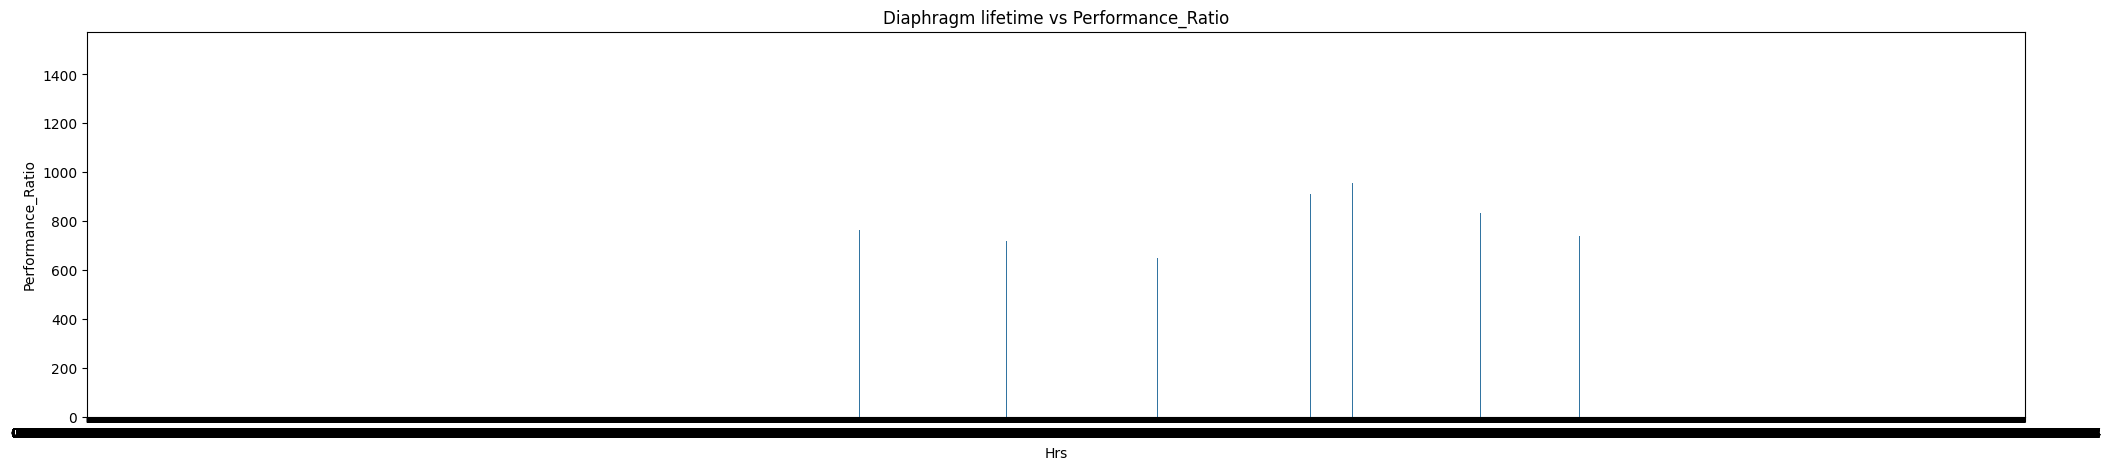

In [38]:
plt.figure(figsize=(25,5))
#plt.xticks(np.arange(np.min(Perf_df.index),np.max((Perf_df.index)),15))
sns.barplot(x=P2_Merg_df['Diaphragm_life'],y=P2_Merg_df['max_point'])
#plt.plot(P2_Merg_df['Diaphragm_life'],P2_Merg_df['max_point'],marker = '.')
plt.xlabel('Hrs')
plt.ylabel('Performance_Ratio')
plt.title('Diaphragm lifetime vs Performance_Ratio')
plt.show()